# Looking inside a vision-language model

**Model:** `Qwen/Qwen3-VL-2B-Instruct` — 2 billion parameters, takes images and text
together, answers in text. Runs on a single Colab **L4 GPU**.

### What this notebook is

A guided tour of what a vision-language model is made of, ending in a real measurement
nobody seems to have published for this model: **how much each layer of its image encoder
actually contributes, and how many of its neurons stay quiet.**

It assumes you know roughly what a neural network is, and nothing else. Every cell is
explained before it runs.

### Why you might care

A model like this is increasingly the thing sitting behind a product — answering
questions about photos, reading documents, or driving a car. When it gets something
wrong, "the model was wrong" is not a useful answer. You want to know *which part* was
wrong. That requires first knowing what the parts are and how work is distributed across
them, which is what this notebook measures.

### What's inside a vision-language model

Two neural networks stacked, with a connector:

```
   image  ──►  VISION TOWER  ──►  connector  ──►  LANGUAGE MODEL  ──►  text answer
                24 layers                            28 layers
                                                        ▲
   your question ──────────────────────────────────────┘
```

The **vision tower** turns pixels into a sequence of vectors. The **connector** reshapes
those vectors so the language model can read them. The **language model** sees your
question and the image-vectors side by side, as one sequence, and writes an answer.

This notebook focuses on the vision tower, because it is small enough (about 0.4 billion
of the 2 billion parameters) to examine exhaustively.

### Contents

| section | what happens |
|---|---|
| 0, 0b | install, detect the GPU, work around a Colab bug |
| 1 | read the model's blueprint before downloading it |
| 2 | load it |
| 3 | find out what the parts are actually named in code |
| 4 | how an image becomes something a transformer can read |
| 5 | ask it a question |
| 6 | the two different neuron designs inside it |
| 7 | **the measurement** |

> Results here come from **five images**. That is enough to demonstrate the method and
> not nearly enough to publish. Read section 7's caveats before quoting any number.

## 0 · Setup

Install the library that knows this model's architecture, and check what GPU we got.

**Why the version check matters.** `transformers` is the library that defines model
architectures in code. Qwen3-VL is recent enough that older versions have never heard of
it, and they fail with a confusing error much later — after a 4 GB download. So we assert
the version immediately and fail loudly if it is wrong.

**Why the GPU check matters.** Numbers inside a neural network are stored in a compact
floating-point format. There are two common 16-bit ones:

- **float16** — more precision, smaller range
- **bfloat16** — less precision, much larger range, and far more forgiving of the very
  large and very small values that show up inside big models

This checkpoint was trained in bfloat16. But **not every GPU can do bfloat16**: it needs
NVIDIA "compute capability" 8.0 or higher. An **L4** is 8.9 and can. A **T4** — the free
Colab default — is 7.5 and cannot, so it has to fall back to float16.

Asking a T4 for bfloat16 produces a baffling failure, so the cell below picks the format
from the hardware instead of hoping.

In [1]:
!pip -q install "transformers>=4.57.0" accelerate pillow
!git clone -q https://github.com/thebnbrkr/marv-vision.git 2>/dev/null || echo "already cloned"
%cd /content/marv-vision

import transformers, torch
print("transformers", transformers.__version__, "| torch", torch.__version__, "| cuda", torch.version.cuda)
assert tuple(int(x) for x in transformers.__version__.split('.')[:2]) >= (4, 57), \
    f"need transformers >= 4.57 for Qwen3-VL, got {transformers.__version__}"


/content/marv-vision
transformers 5.17.0 | torch 2.11.0+cu130 | cuda 13.0


In [2]:
import torch, sys

if not torch.cuda.is_available():
    raise SystemExit("No GPU. Runtime -> Change runtime type -> L4 GPU.")

name = torch.cuda.get_device_name(0)
major, minor = torch.cuda.get_device_capability()
HAS_BF16 = major >= 8
DTYPE = torch.bfloat16 if HAS_BF16 else torch.float16

print(f"GPU        : {name}  (compute {major}.{minor})")
print(f"VRAM       : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"bfloat16   : {HAS_BF16}")
print(f"-> using   : {DTYPE}")
if not HAS_BF16:
    print("\n   T4 detected. The checkpoint is bf16 but this GPU has none, so we load")
    print("   fp16 instead. Passing dtype='auto' here is the trap that cost marv-hyena a round.")

GPU        : NVIDIA L4  (compute 8.9)
VRAM       : 23.7 GB
bfloat16   : True
-> using   : torch.bfloat16


## 0b · Working around a Colab bug

**This is not optional, and it is not a bug in this notebook.**

PyTorch does not ship a precompiled routine for every possible operation. For some, it
writes the GPU code on the fly and compiles it at runtime, using a compiler called NVRTC.
That compiler needs a support library, `libnvrtc-builtins.so`.

On Colab right now, that library is installed — but in a place NVRTC does not look. So
any operation needing runtime compilation fails with a wall of generated C++ ending in:

```
nvrtc: error: failed to open libnvrtc-builtins.so.13.0
```

This bites here because Qwen3-VL computes how many patches an image was cut into with a
`.prod()` call, and that is one of the operations PyTorch compiles at runtime. **Three
integers multiplied together** is enough to kill the whole forward pass.

Tracked as [googlecolab/colabtools#6111](https://github.com/googlecolab/colabtools/issues/6111).

The next cell finds the library and links it into the places NVRTC searches. The cell
after that **tests the exact operation that fails**, rather than assuming the fix worked.

In [3]:
import glob, os, subprocess

builtins = sorted(glob.glob("/usr/local/lib/python3*/dist-packages/nvidia/**/libnvrtc-builtins.so*", recursive=True))
nvrtc    = sorted(glob.glob("/usr/local/lib/python3*/dist-packages/nvidia/**/libnvrtc.so*", recursive=True))
print("builtins found:", builtins or "NONE")
print("libnvrtc found:", nvrtc or "NONE")

linked = []
if builtins:
    src  = builtins[0]
    base = os.path.basename(src)
    dirs = ["/usr/lib/x86_64-linux-gnu", "/usr/local/cuda/lib64", "/usr/local/lib"]
    if nvrtc:
        dirs.insert(0, os.path.dirname(nvrtc[0]))     # NVRTC looks beside itself first
    for d in dirs:
        if not os.path.isdir(d):
            continue
        dst = os.path.join(d, base)
        if os.path.exists(dst):
            continue
        try:
            os.symlink(src, dst); linked.append(dst)
        except OSError as e:
            print("  skip", dst, e)
    subprocess.run(["ldconfig"], check=False)
    os.environ["LD_LIBRARY_PATH"] = os.path.dirname(src) + ":" + os.environ.get("LD_LIBRARY_PATH", "")

print("symlinked ->", linked or "nothing new")

builtins found: ['/usr/local/lib/python3.13/dist-packages/nvidia/cu13/lib/libnvrtc-builtins.so.13.0', '/usr/local/lib/python3.13/dist-packages/nvidia/cuda_nvrtc/lib/libnvrtc-builtins.so.12.9']
libnvrtc found: ['/usr/local/lib/python3.13/dist-packages/nvidia/cu13/lib/libnvrtc.so.13', '/usr/local/lib/python3.13/dist-packages/nvidia/cuda_nvrtc/lib/libnvrtc.so.12']
symlinked -> ['/usr/lib/x86_64-linux-gnu/libnvrtc-builtins.so.13.0', '/usr/local/cuda/lib64/libnvrtc-builtins.so.13.0', '/usr/local/lib/libnvrtc-builtins.so.13.0']


In [4]:
# THE test. This is the exact op that fails inside get_image_features.
import torch

try:
    g = torch.tensor([[1, 32, 46]], device="cuda")
    print("cuda prod OK:", g.prod(-1).tolist())
    NVRTC_OK = True
except RuntimeError as e:
    NVRTC_OK = False
    print("still broken:", str(e).strip().splitlines()[-1])
    print("\n-> run the FALLBACK cell below, then carry on.")

cuda prod OK: [1472]


### If the test above still failed

Two options, cheapest first.

**A. Restart and rerun.** `Runtime → Restart session`, then run from the top. The links
survive a restart, and a fresh process re-reads where to look for libraries. This usually
does it.

**B. Move that one calculation to the CPU.** The failing operation multiplies three small
integers and immediately converts the result to a plain Python list. Nothing is lost by
doing it on the CPU. The cell below patches only that narrow case — small integer
multiplications on the GPU — and leaves everything else untouched.

If the test passed, the cell below does nothing.

In [5]:
# FALLBACK B -- only run this if the cuda prod test above failed.
if not NVRTC_OK:
    _real_prod = torch.Tensor.prod

    def _cpu_prod(self, *a, **k):
        # route only the tiny int64 grid reductions through the CPU; everything
        # else keeps its normal (precompiled) GPU kernel
        if self.is_cuda and self.dtype in (torch.int32, torch.int64) and self.numel() <= 64:
            return _real_prod(self.cpu(), *a, **k).to(self.device)
        return _real_prod(self, *a, **k)

    torch.Tensor.prod = _cpu_prod
    print("patched torch.Tensor.prod for small integer CUDA tensors")
    print("check:", torch.tensor([[1, 32, 46]], device="cuda").prod(-1).tolist())
else:
    print("not needed -- NVRTC is working")

not needed -- NVRTC is working


## 1 · Reading the blueprint before downloading the model

Every model on Hugging Face ships a `config.json` — a small text file describing its
shape. You can read it without downloading the 4 GB of weights, which makes it a cheap
way to know what you are dealing with.

### The vocabulary you need

Each layer of a transformer has two parts:

- **attention** — lets positions look at each other ("this patch relates to that one")
- **a feed-forward network (FFN)** — processes each position on its own

The FFN is where most parameters live, and it has a simple shape: expand to a wider
space, apply a nonlinearity, squeeze back down.

```
   1024 numbers  ──►  4096 numbers  ──►  nonlinearity  ──►  1024 numbers
      (in)            ("intermediate")                        (out)
```

Each of those 4096 intermediate slots is one **neuron**, also called a **feature**. It is
the smallest unit you can point at and switch off. Counting them tells you how many
things there are to examine:

```
   features in a tower  =  number of layers  ×  intermediate size
```

**Nonlinearity** just means a simple function applied to each number separately, which is
what lets the network represent anything more interesting than a straight line. Two
common ones appear here: **SiLU** and **GELU**. They are nearly the same shape — smooth
curves that pass large positive numbers through and squash negative ones toward zero.

In [6]:
!python scripts/inspect_model.py --no-load

config.json: 100% 1.50k/1.50k [00:00<00:00, 3.77MB/s]

Qwen/Qwen3-VL-2B-Instruct

  text     28 layers  hidden 2048  inter 6144  silu               gated       172,032 features
  vision   24 layers  hidden 1024  inter 4096  gelu_pytorch_tanh  NOT gated    98,304 features
  total                                                                          270,336 features

  DeepStack taps vision layers: 5 (21%), 11 (46%), 17 (71%) of 24
  tie_word_embeddings=True -> lm_head IS embed; do not store two copies



### What that output means

| | vision tower | language model |
|---|---|---|
| layers | 24 | 28 |
| width | 1024 | 2048 |
| FFN intermediate size | 4096 | 6144 |
| nonlinearity | GELU | SiLU |
| **neurons** | **98,304** | **172,032** |

**270,336 neurons in total.** That number is the point of this whole exercise. It is
large, but small enough to look at *every single one* rather than sampling — which is
usually impossible on bigger models.

### The interesting line: `deepstack_visual_indexes: [5, 11, 17]`

The vision tower has 24 layers. You would expect the language model to receive the output
of the last one. It does — but it *also* receives copies of what layers **5, 11 and 17**
produced, injected separately. Qwen calls this **DeepStack**.

Why build that? Because of a finding that keeps recurring in vision research: **the most
useful image features are often not at the end of the network.** The last layers compress
toward whatever the training objective rewarded, throwing away detail that other tasks
would want. Tapping the middle recovers it.

So the architecture is telling you where it thinks its own useful information lives. That
is worth remembering when we measure the layers in section 7.

### `tie_word_embeddings: true`

The table that converts words into vectors at the input, and the table that converts
vectors back into words at the output, are **the same table**. A common space-saving
trick — and a trap if you write code that stores both, because you would keep two copies
of a 1.2 GB matrix.

## 2 · Loading the model

Downloads about 4 GB and puts it on the GPU in the format section 0 chose.

`AutoProcessor` is the input pipeline: it resizes images, cuts them into patches,
converts text into numbers, and assembles both into the single sequence the model reads.

In [7]:
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

MODEL = "Qwen/Qwen3-VL-2B-Instruct"
model = Qwen3VLForConditionalGeneration.from_pretrained(MODEL, dtype=DTYPE, device_map="cuda")
model.eval()
proc = AutoProcessor.from_pretrained(MODEL)

n = sum(p.numel() for p in model.parameters())
print(f"{n/1e9:.2f}B params, {torch.cuda.memory_allocated()/1e9:.1f} GB on GPU")

model.safetensors: reconstructing file:   0%|          |  0.00B / 4.26GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

2.13B params, 4.3 GB on GPU


## 3 · What are the parts actually called in code?

The blueprint told us the *shape* of the model. It does not tell us the **names** the
parts have as Python objects — and we need those to attach measuring instruments.

This is fiddlier than it sounds. Different model families nest their parts differently
(`model.visual.blocks` versus `model.vision_tower.layers` versus …), and the names change
between library versions. So rather than guess, the next cell tries the plausible
locations and **reports which one actually resolved.**

The cell after prints the full structure, which is worth reading once even if you skim
it — you can see the whole architecture laid out.

### One thing to watch for

The output includes a warning:

> `NOTE: last child is 'act_fn', NOT the second matrix ('linear_fc2').`

Inside each vision FFN there are three registered components, in this order:

```
   linear_fc1   the first matrix     (expands 1024 → 4096)
   linear_fc2   the second matrix    (squeezes 4096 → 1024)
   act_fn       the nonlinearity     (GELU)
```

They are listed in the order they were *defined*, not the order they *run*. So "the last
component" is the nonlinearity, not the second matrix. Grabbing parts by position instead
of by name is a genuine trap here — it silently attaches your instrument to the wrong
thing and gives you confident, wrong numbers. Always name the part you want.

In [8]:
from marv_vision.arch import describe_model

paths = describe_model(model)
paths

text layers   : model.language_model.layers  (28 layers)
vision blocks : model.visual.blocks  (24 blocks)

text  mlp type: Qwen3VLTextMLP
      children: ['gate_proj', 'up_proj', 'down_proj', 'act_fn']
      gated (gate_proj/up_proj/down_proj) present: True

vision mlp type: Qwen3VLVisionMLP
       children: ['linear_fc1', 'linear_fc2', 'act_fn']
       resolved: ('linear_fc1', 'linear_fc2')
       NOTE: last child is 'act_fn', NOT the second matrix ('linear_fc2'). Never index children by position.


{'text_layers_path': 'model.language_model.layers',
 'vision_blocks_path': 'model.visual.blocks',
 'text_mlp_attrs': ('gate_proj', 'up_proj', 'down_proj'),
 'vision_mlp_attrs': ('linear_fc1', 'linear_fc2')}

In [9]:
# The full tree, if the above left anything ambiguous.
# Long -- skim the two `mlp` entries, that is what matters.
print(model)

Qwen3VLForConditionalGeneration(
  (model): Qwen3VLModel(
    (visual): Qwen3VLVisionModel(
      (patch_embed): Qwen3VLVisionPatchEmbed(
        (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
      (pos_embed): Embedding(2304, 1024)
      (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-23): 24 x Qwen3VLVisionBlock(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): Qwen3VLVisionAttention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (mlp): Qwen3VLVisionMLP(
            (linear_fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (linear_fc2): Linear(in_features=4096, out_features=1024, bias=True)
            (act_fn): GELUTanh()
          )
        )
      )
 

Every location resolved, so we know exactly where to attach instruments:

```
language model : model.language_model.layers   28 layers
vision tower   : model.visual.blocks           24 blocks
```

A few details worth noting from the full structure above:

- **`patch_embed` is a `Conv3d`** with kernel `(2, 16, 16)` — the 16×16 is the image
  patch, and the leading 2 is *time*, because the same encoder handles video by taking
  two frames at once.
- **The vision FFN matrices have a bias, the language FFN matrices do not.** A small
  difference, but it means a vision neuron has a nonzero default output even with zero
  input.
- **`merger`** is the connector: it takes 4096 numbers (four patches of 1024, merged) and
  produces the 2048 the language model expects.
- **`deepstack_merger_list`** has exactly 3 entries — one for each of layers 5, 11, 17.

## 4 · How an image becomes something a transformer can read

This is the central idea, and it is simpler than people expect.

A language model reads text by chopping it into **tokens** — roughly words — and looking
each one up in a table to get a vector.

A vision transformer reads an image by chopping it into **square patches** of 16×16
pixels, flattening each patch into a list of numbers, and multiplying by one matrix to
get a vector.

```
   TEXT              "the cat sat"
                      ↓ split into words
                     [the] [cat] [sat]
                      ↓ look each up in a table
                     vectors

   IMAGE             ┌─┬─┬─┬─┐
                     ├─┼─┼─┼─┤   split into 16×16 squares
                     ├─┼─┼─┼─┤
                     └─┴─┴─┴─┘
                      ↓ flatten each square, multiply by one matrix
                     vectors
```

**That is the only difference at the input.** After this point both are just a sequence
of vectors, and the transformer treats them identically. So in a vision transformer, a
"token" is simply one patch of the image.

The next two cells load an image and show how many tokens it becomes.

image size: (960, 686)


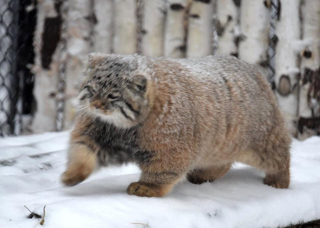

In [10]:
from PIL import Image
import requests, math

URL = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
img = Image.open(requests.get(URL, stream=True).raw).convert("RGB")
print("image size:", img.size)
img.resize((320, int(320*img.size[1]/img.size[0])))

In [11]:
msgs = [{"role": "user", "content": [
    {"type": "image", "image": URL},
    {"type": "text",  "text": "Describe this image."}]}]

inputs = proc.apply_chat_template(msgs, tokenize=True, add_generation_prompt=True,
                                 return_dict=True, return_tensors="pt").to(model.device)

cfg  = model.config.vision_config
px   = inputs["pixel_values"]
n_img_tok = int((inputs["input_ids"][0] == model.config.image_token_id).sum())

print(f"pixel_values shape : {tuple(px.shape)}")
print(f"patch size         : {cfg.patch_size}x{cfg.patch_size} pixels")
print(f"spatial_merge_size : {cfg.spatial_merge_size}  (2x2 patches merged into 1 token)")
print(f"total sequence     : {inputs['input_ids'].shape[1]} tokens")
print(f"  of which VISUAL  : {n_img_tok}")
print(f"  of which text    : {inputs['input_ids'].shape[1] - n_img_tok}")

pixel_values shape : (2520, 1536)
patch size         : 16x16 pixels
spatial_merge_size : 2  (2x2 patches merged into 1 token)
total sequence     : 644 tokens
  of which VISUAL  : 630
  of which text    : 14


### The number that matters here

```
total sequence : 644 tokens
  of which VISUAL : 630
  of which text   :  14
```

**98% of what the model is reading is the image.** One ordinary photo produces 45× more
tokens than the question about it.

Two consequences:

**Memory.** The model's weights are 4 GB and fixed. The *tokens* are what grows, and
attention cost grows faster than the token count. This is why a single photo is
comfortable and a 20-second video from six cameras is a completely different problem —
the weights did not change, the sequence did.

**Where to look.** If almost everything in the sequence came from the image, then most of
what the language model is working with was produced by the vision tower. That is an
argument for examining the vision tower, which is what section 7 does.

### Why 630 and not 2520

The image was cut into **2520** patches of 16×16 pixels. But `spatial_merge_size: 2` means
each **2×2 block of neighbouring patches is merged into one token** before the language
model sees it: 2520 ÷ 4 = 630.

So the vision tower internally works with 2520 positions; the language model receives 630.

## 5 · Asking it a question

Everything so far was structural. This confirms the model actually works: image in,
sensible sentence out.

In [12]:
with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=64, do_sample=False)
trimmed = out[0][inputs["input_ids"].shape[1]:]
print(proc.decode(trimmed, skip_special_tokens=True))

This image captures a **Pallas's cat** (*Otocolobus manul*) in a snowy, winter environment. The animal is the central focus, shown in motion as it walks across a snow-covered ground.

Here is a detailed description of the image:

- **The Animal**: The Pallas's cat is


## 6 · Two different neuron designs in one model

The two towers build their feed-forward networks differently. This is the main reason
tools written for language models do not transfer to vision encoders unchanged.

**Language model — "gated", three matrices:**

```
              ┌── gate_proj ──► SiLU ──┐
   input ─────┤                        ✕ ──► down_proj ──► output
              └── up_proj ─────────────┘
```

Two separate matrices read the input and their results are multiplied together.
`gate_proj` decides *whether* a neuron should fire; `up_proj` decides *how much*. Because
`gate_proj` does nothing but detect, you can examine it on its own and ask "which neurons
respond to this kind of input?" and get a clean answer.

**Vision tower — "not gated", two matrices:**

```
   input ─────► linear_fc1 ──► GELU ──► linear_fc2 ──► output
```

One matrix, doing detection and magnitude at the same time. A large value could mean
"strongly detected" or just "large numbers". The same question gets a blurrier answer.

**Note what is *not* the important difference.** GELU versus SiLU is nearly irrelevant —
both are smooth curves of almost the same shape. The structural difference is **how many
matrices read the input**, and that is what changes which questions you can ask.

In both designs, a neuron `f` is:

- **row `f`** of the first matrix — what it looks for
- **column `f`** of the last matrix — what it writes when it fires

The cell below prints the real shapes.

In [13]:
tl = model.model.language_model.layers if hasattr(model.model, "language_model") else model.model.layers
vb = model.model.visual.blocks

print("TEXT tower MLP (gated -- three matrices):")
for nme, p in tl[0].mlp.named_parameters():
    print(f"   {nme:<20} {tuple(p.shape)}")

print("\nVISION tower MLP (not gated -- two matrices):")
for nme, p in vb[0].mlp.named_parameters():
    print(f"   {nme:<20} {tuple(p.shape)}")

TEXT tower MLP (gated -- three matrices):
   gate_proj.weight     (6144, 2048)
   up_proj.weight       (6144, 2048)
   down_proj.weight     (2048, 6144)

VISION tower MLP (not gated -- two matrices):
   linear_fc1.weight    (4096, 1024)
   linear_fc1.bias      (4096,)
   linear_fc2.weight    (1024, 4096)
   linear_fc2.bias      (1024,)


### Reading those shapes

```
VISION:  linear_fc1.weight  (4096, 1024)   ← 4096 neurons, each reading 1024 inputs
         linear_fc2.weight  (1024, 4096)   ← 4096 columns, each writing 1024 outputs
```

Neuron 137 of this layer is **row 137 of `linear_fc1`** and **column 137 of
`linear_fc2`**. That pairing is what makes a single neuron a thing you can point at,
measure, and switch off. There are 4096 per layer and 24 layers.

Note the vision matrices have `.bias` entries and the language ones do not.

## 7 · The measurement

Now the actual experiment. Two questions about the vision tower's 98,304 neurons:

### Question 1: how many of them do anything?

Neural networks are trained with far more capacity than they end up using, and some
neurons end up effectively switched off. That matters for a practical reason: if you pick
a neuron and go looking for what it detects, **you will always find something** — you can
always show the nine images that made it respond most. If the neuron is dead, those nine
images are noise, and you have invented a finding.

So: count the quiet ones *first*, before interpreting any of them.

### Question 2: do all layers contribute equally?

Each layer adds its output into a running total that flows through the network. If one
layer's contribution is enormously larger than the rest, the final answer is effectively
a function of that one layer alone — and every tool that tries to apportion credit across
layers will just point at it, correctly and uselessly.

That failure mode is real and has been found in other architectures. It is cheap to check
and expensive to discover late, so we check.

### How we measure

We attach a **hook** — a listener that records values passing through a chosen point
without altering them — at the input to `linear_fc2`. That point holds each neuron's
output *after* the nonlinearity, which is exactly its activation.

For each neuron we record its **peak** value across every patch of every image. Then we
compute what actually matters:

```
   contribution  =  peak activation  ×  length of that neuron's output column
```

Why multiply? Because a neuron with a huge activation whose output column is near zero
moves nothing. Activation alone is misleading; activation times the size of what it
writes is the real influence.

### The check that comes first

Before trusting any of it, cell 30 verifies the hook is in the right place. Here is the
trick: **GELU's output can never go below about −0.170.** That is a mathematical property
of the function. Values *before* the nonlinearity have no such limit and routinely go far
more negative.

So if the minimum we recorded respects that floor, we are reading post-activation values
and the hook is correct. If it does not, the hook is in the wrong place and every number
after it is meaningless. The check prints which.

This is worth the cell. An earlier version of this notebook attached the hook to the
nonlinearity instead of the matrix, measured pre-activation values, and reported a clean,
confident, completely wrong result. This check catches that automatically.

In [14]:
# The image set. Four is a toy; extend this before quoting any number.
# A neuron that only fires on traffic cones looks silent if you never show it one.
BASE = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/"
IMAGES = [
    BASE + "pipeline-cat-chonk.jpeg",
    BASE + "coco_sample.png",
    BASE + "bee.jpg",
    BASE + "transformers/tasks/ai2d-demo.jpg",
    BASE + "transformers/model_doc/llava_v1_5_radar.jpg",
    BASE + "transformers/tasks/idefics-few-shot.jpg",
    BASE + "cat-chonk.jpeg",
    BASE + "transformers/model_doc/pix2struct_screen.png",
]

# Drop any that 404 rather than dying mid-sweep.
import requests
from PIL import Image
from io import BytesIO

ok = []
for u in IMAGES:
    try:
        r = requests.get(u, timeout=20)
        r.raise_for_status()
        Image.open(BytesIO(r.content)).convert("RGB")
        ok.append(u)
    except Exception as e:
        print(f"  skip {u.rsplit('/',1)[-1]}: {type(e).__name__}")
IMAGES = ok

print(f"\n{len(IMAGES)} images usable -- PRELIMINARY.")
print("A reportable number needs hundreds of diverse images, and driving images")
print("before any claim about driving.")


  skip llava_v1_5_radar.jpg: HTTPError
  skip cat-chonk.jpeg: HTTPError
  skip pix2struct_screen.png: HTTPError

5 images usable -- PRELIMINARY.
A reportable number needs hundreds of diverse images, and driving images
before any claim about driving.


In [15]:
import torch
from marv_vision.arch import VisionTowerFFN

vis = VisionTowerFFN(model)
L, D = len(vis), vis.features(0)
print(f"vision tower: {L} layers x {D} features = {L*D:,}")
print(f"hooking {vis.attrs[1]} (the second MATRIX, not act_fn)")

peak = torch.zeros(L, D, device=model.device, dtype=torch.float32)

def mk(li):
    def pre_hook(mod, args):           # args[0] == input to linear_fc2 == POST-activation
        a = args[0].detach().float().abs().reshape(-1, D)
        peak[li] = torch.maximum(peak[li], a.amax(0))
    return pre_hook

handles = []
try:
    for li in range(L):
        handles.append(vis.second(li).register_forward_pre_hook(mk(li)))
    for u in IMAGES:
        m = [{"role": "user", "content": [{"type": "image", "image": u},
                                          {"type": "text", "text": "Describe this."}]}]
        inp = proc.apply_chat_template(m, tokenize=True, add_generation_prompt=True,
                                       return_dict=True, return_tensors="pt").to(model.device)
        with torch.no_grad():
            model(**inp)
        print(".", end="")
finally:
    for h in handles:
        h.remove()                     # hooks are ALWAYS removed, even on exception
print(" done")

vision tower: 24 layers x 4096 features = 98,304
hooking linear_fc2 (the second MATRIX, not act_fn)
..... done


In [16]:
# sanity check FIRST: are these really post-activation values?
# GELU's minimum is about -0.170; post-activation values cannot go below it.
# Pre-activation values are unbounded, so a large negative minimum means the
# hook is on the wrong module again.
mins = []
h = vis.second(0).register_forward_pre_hook(lambda m, a: mins.append(a[0].detach().float().min().item()))
m = [{"role": "user", "content": [{"type": "image", "image": IMAGES[0]},
                                  {"type": "text", "text": "Describe this."}]}]
inp = proc.apply_chat_template(m, tokenize=True, add_generation_prompt=True,
                               return_dict=True, return_tensors="pt").to(model.device)
with torch.no_grad():
    model(**inp)
h.remove()

print(f"min value seen at linear_fc2 input: {mins[0]:.4f}")
print("GELU floor is ~ -0.1700")
print("POST-activation (hook correct)" if mins[0] > -0.25 else
      "PRE-activation -- HOOK IS WRONG, the numbers below mean nothing")

min value seen at linear_fc2 input: -0.1699
GELU floor is ~ -0.1700
POST-activation (hook correct)


In [17]:
# contribution = how far a neuron can actually push the residual
colnorm = torch.stack([vis.write_norms(li) for li in range(L)])     # (L, D)
contrib = peak * colnorm

print(f"{'':5} {'peak |act|':>28}   {'contribution':>28}")
print(f"{'layer':5} {'median':>9}{'min':>9}{'<1% med':>10}   {'median':>9}{'min':>9}{'<1% med':>10}")
for li in range(L):
    pk, ct = peak[li], contrib[li]
    pm, cm = pk.median().item(), ct.median().item()
    print(f"L{li:<4} {pm:>9.3f}{pk.min().item():>9.4f}{int((pk < .01*pm).sum()):>10}"
          f"   {cm:>9.3f}{ct.min().item():>9.4f}{int((ct < .01*cm).sum()):>10}")

quiet = contrib < 0.01 * contrib.median(dim=1, keepdim=True).values
print(f"\nneurons contributing <1% of their layer median: {int(quiet.sum()):,} "
      f"({quiet.float().mean():.2%})   [{len(IMAGES)} images -- PRELIMINARY]")

                        peak |act|                   contribution
layer    median      min   <1% med      median      min   <1% med
L0        0.867   0.0000        15       0.490   0.0000        12
L1        1.281   0.0000       198       0.614   0.0000       190
L2        1.266   0.0000       713       0.593   0.0000       716
L3        0.373   0.0000       542       0.200   0.0000       543
L4        0.350   0.0000       341       0.207   0.0000       340
L5        0.988   0.0000       245       0.479   0.0000       248
L6        1.023   0.0000        32       0.507   0.0000        31
L7        1.227   0.0996         0       0.606   0.0610         0
L8        1.406   0.1562         0       0.689   0.0577         0
L9        1.367   0.1309         0       0.648   0.0652         0
L10       1.438   0.1348         0       0.703   0.0630         0
L11       1.109   0.0771         0       0.614   0.0666         0
L12       1.359   0.1699         0       0.759   0.0839         0
L13       

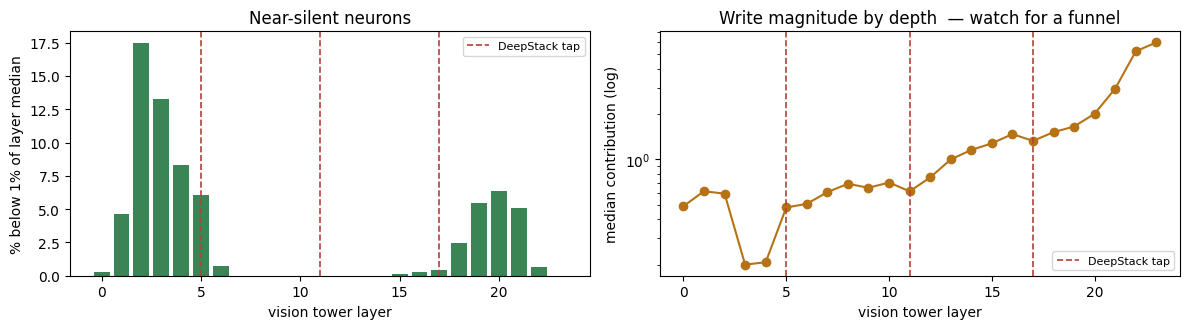

In [18]:
import matplotlib.pyplot as plt

ds = model.config.vision_config.deepstack_visual_indexes
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))

ax[0].bar(range(L), (quiet.float().mean(1) * 100).cpu(), color="#3A8455")
ax[0].set_ylabel("% below 1% of layer median"); ax[0].set_title("Near-silent neurons")

ax[1].plot(range(L), contrib.median(1).values.cpu(), "o-", color="#B57316")
ax[1].set_yscale("log"); ax[1].set_ylabel("median contribution (log)")
ax[1].set_title("Write magnitude by depth  — watch for a funnel")

for a in ax:
    a.set_xlabel("vision tower layer")
    for i, t in enumerate(ds):
        a.axvline(t, color="#B0423A", ls="--", lw=1.2, label="DeepStack tap" if i == 0 else None)
    a.legend(fontsize=8)
plt.tight_layout(); plt.show()

## What the numbers say

### The check passed, tightly

```
min value seen at linear_fc2 input : -0.1699
GELU floor is                      ~ -0.1700
POST-activation (hook correct)
```

The lowest value recorded sits one ten-thousandth above GELU's mathematical floor. The
instrument is measuring what we think it is measuring.

### Result 1 — no single layer dominates

Median contribution rises from about **0.5** in the early layers to about **6.0** at layer
23. That is roughly a **12×** increase, spread gradually across 24 layers, with the
steepest rise in the last three.

A 12× spread over 24 layers is unremarkable — later layers doing more work is normal and
expected. What matters is what we did *not* find: no single layer whose contribution
dwarfs all the others by orders of magnitude.

**That is a green light.** Techniques that apportion credit across layers should give
meaningful, distributed answers in this tower rather than collapsing onto one layer.

It is also worth noting where DeepStack taps: layers **5, 11 and 17** — all *before* the
steep rise at 21–23. The architecture pulls its extra features from the middle of the
stack, not the loud end.

### Result 2 — about 3% of neurons stay quiet, in a striking pattern

**2,935 of 98,304 (2.99%)** contributed less than 1% of their layer's median. But they are
not spread evenly:

```
   L0             15
   L1–L5     198 → 713 → 542 → 341 → 245       quiet cluster
   L6             32
   L7–L13     0   0   0   0   0   0   0        completely dense — not one
   L14–L17    1   6  14  18
   L18–L21  107 228 264 214                    quiet cluster
   L22            30
   L23             0
```

Quiet at both ends, entirely dense in the middle. Layers 7 to 13 have **zero** neurons
below the threshold — every one of the 4096 in each of those seven layers is doing
something measurable.

### What this probably means — and the limit on saying so

The honest reading is that **with five images you cannot tell "narrowly tuned" from
"dead"**. A neuron that only responds to text, or faces, or a particular texture will look
silent if you never show it one. Narrow specialists in the early layers are exactly what
you would expect.

That makes this a **prediction rather than a conclusion**, and a testable one:

> With several hundred diverse images, the quiet clusters at layers 1–5 and 18–21 should
> **shrink substantially**, while the dense band at 7–13 stays dense. If the quiet clusters
> *do not* shrink, those neurons are genuinely unused.

That is the next experiment, and the current result is what makes it worth running.

### Three caveats on the numbers above

1. **Five images.** Three of the intended eight returned HTTP errors and were skipped.
   Five demonstrates the method; it does not support a published number.
2. **The `0.0000` minimums are not true silence.** GELU applied to a strongly negative
   input produces something like 10⁻⁸⁸, which is too small for bfloat16 to represent and
   becomes exactly zero. Those neurons are strongly *suppressed*, not absent.
3. **Peak *absolute* value merges two different states.** A neuron pinned at GELU's floor
   (−0.17) is maximally suppressed, but registers the same magnitude as a mildly active
   one. For contribution this is defensible — a negative write still moves the total — but
   for "is this neuron ever on", positive and negative peaks should be tracked separately.

## What to do next

1. **More images, verified.** A few hundred diverse ones, with URLs checked in advance.
   This is what turns the prediction above into a result.
2. **Track positive and negative peaks separately**, so suppression and activation stop
   being merged.
3. **Count the exact zeros explicitly** and label them as numeric underflow rather than
   silence.
4. **Then, and only then, ask what individual neurons detect** — and do it against
   labelled data (segmentation masks, object boxes) so the answer is a number with an
   expected baseline, rather than nine hand-picked images that always look convincing.

### The one habit worth taking from this notebook

Every measurement asserts its own precondition before reporting. The GELU-floor check in
cell 30 exists because an earlier version of this notebook got that exact thing wrong and
produced a clean, confident, false result. It looked completely reasonable.

A check you have to remember to look at is not a check.